PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [1]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [18]:
#libreria para graficos 3D
from mpl_toolkits.mplot3d import Axes3D

In [3]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

Como sabemos que tenemos un grupo de datos muy amplio, de diferentes grupos (competencias, paises, generos) lo primero que se realizo fue filtrar la cantidad de temporadas disponibles por campeonato, y de esta manera usar aquella liga o torneo que nos proporcione datos en masa y de calidad. Asi logramos conocer que disponemos de 17 temporadas de la liga masculina del futbol español (La Liga).

In [2]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
#VARIABLES A DEJAR: competition_id; season_id; competition_name; season_name
#seasons = [[37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]] - seasons_id
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(17)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


No solo nos quedamos con la eleccion de las temporadas, y tampoco lo hicimos "porque si"; a continuacion se logra observar un grafico de dispersion donde se ve un conjunto de valores mayor y menos disperso desde el año 2004 a 2021

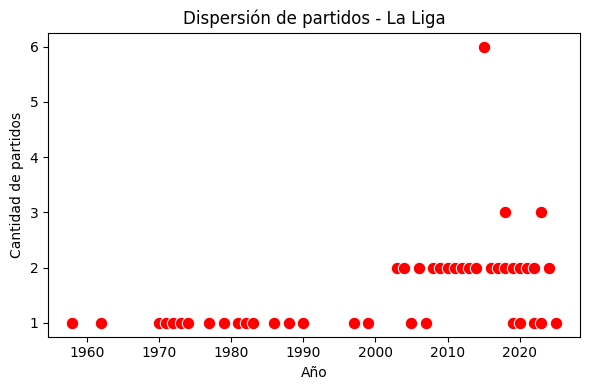

In [14]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos - La Liga')
plt.tight_layout()
plt.show()


In [ ]:
#variables - matches
#DEJAR EN EL DATASET: match_date; home_team; away_team;home_score; away_score; match_week; competition_stage; stadium; home_managers; away_managers
matches = sb.matches(competition_id=11,season_id=90);
matches.head(1)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,...,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


Conociendo la ubicacion cronologica de la mayoria de los datos a trabajar, se comenzo el proceso de unificacion de tablas para asi hacer más valiosos y brindarle significado a cada uno de los datos. Como primer unificacion se junto la tabla de las 17 temporadas (competitions) con cada uno de sus partidos.

In [16]:
#merge de competitions + matches (mediante competition_id y season_id)
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

competitions_reduce = sb.competitions()[['competition_id','season_id',
                                'competition_name','season_name','country_name']].drop_duplicates()

all_matches = []
for sid in seasons:
    m = sb.matches(competition_id=competition_id, season_id=sid)
    m['competition_id'] = 11
    m['season_id'] = sid

    m = m[['match_id','competition_id','season_id','match_date',
           'home_team','away_team','home_score','away_score',
           'match_week','competition_stage','stadium',
           'home_managers','away_managers']].copy()
    all_matches.append(m)

matches_df = pd.concat(all_matches, ignore_index=True)
# Ordenar por fecha descendente
matches_df = matches_df.sort_values('match_date', ascending=False).reset_index(drop=True)
# #sid == season_id
# #m == matches

merged = matches_df.merge(competitions_reduce, on=['competition_id','season_id'], how='left')

print(merged.shape)
merged


(867, 16)


,match_id,competition_id,season_id,match_date,home_team,away_team,home_score,away_score,match_week,competition_stage,stadium,home_managers,away_managers,competition_name,season_name,country_name
0,3773457,11,90,2021-05-16,Barcelona,Celta Vigo,1,2,37,Regular Season,Spotify Camp Nou,Ronald Koeman,Eduardo Germán Coudet,La Liga,2020/2021,Spain
1,3773387,11,90,2021-05-11,Levante UD,Barcelona,3,3,36,Regular Season,Estadio Ciudad de Valencia,Francisco José López Fernández,Ronald Koeman,La Liga,2020/2021,Spain
2,3773372,11,90,2021-05-08,Barcelona,Atlético Madrid,0,0,35,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Pablo Simeone,La Liga,2020/2021,Spain
3,3773695,11,90,2021-05-02,Valencia,Barcelona,2,3,34,Regular Season,Estadio de Mestalla,Javier Gracia Carlos,Ronald Koeman,La Liga,2020/2021,Spain
4,3773586,11,90,2021-04-29,Barcelona,Granada,1,2,33,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Martínez Penas,La Liga,2020/2021,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,68315,11,37,2004-12-21,Barcelona,Levante UD,2,1,17,Regular Season,Spotify Camp Nou,Frank Rijkaard,Bernd Schuster,La Liga,2004/2005,Spain
863,69153,11,37,2004-12-11,Albacete,Barcelona,1,2,15,Regular Season,Estadio Carlos Belmonte,José Manuel González López,Frank Rijkaard,La Liga,2004/2005,Spain
864,68314,11,37,2004-12-04,Barcelona,Málaga,4,0,14,Regular Season,Spotify Camp Nou,Frank Rijkaard,Gregorio Manzano Ballesteros,La Liga,2004/2005,Spain
865,68313,11,37,2004-10-24,Barcelona,Osasuna,3,0,8,Regular Season,Spotify Camp Nou,Frank Rijkaard,Javier Aguirre Onaindía,La Liga,2004/2005,Spain


Obteniendo esa unificacion, bien se sabe que en cada partido tiene miles de eventos. Por ello primero se filtraron las variables dentro de eventos (events). A continuacion

In [ ]:
#Visualizacion de todas las variables de events
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

all_types = set()
for sid in seasons:
    matches = sb.matches(competition_id, sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())

print(sorted(all_types))

['50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Camera On', 'Camera off', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Error', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Half End', 'Half Start', 'Injury Stoppage', 'Interception', 'Miscontrol', 'Offside', 'Own Goal Against', 'Own Goal For', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Referee Ball-Drop', 'Shield', 'Shot', 'Starting XI', 'Substitution', 'Tactical Shift']


In [9]:
all_events=[]

for sid in seasons:
    matches = sb.matches(competition_id,sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())
        filtered_ev=ev[ev['type'].isin(all_types)]
        all_events.append(filtered_ev)

events_df = pd.concat(all_events, ignore_index=True)
# display(events_df)

Por cada una de estas variables o columnas hay events  indivuales. Por ejemplo 'shot' -> se desglosa en algunos datos como 'shot_statsbomb_xg','shot_outcome' lo q se puede filtrar por jugador, minuto, partido, etc. 
Eventos posibles:['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Dribble' 'Duel' 'Clearance' 'Ball Recovery' 'Shot' 'Goal Keeper'
 'Interception' 'Miscontrol' 'Foul Committed' 'Foul Won' 'Dispossessed'
 'Dribbled Past' 'Block' 'Player Off' 'Player On' 'Substitution'
 'Tactical Shift' 'Half End' 'Injury Stoppage' 'Referee Ball-Drop' '50/50'
 'Shield' 'Offside' 'Bad Behaviour' 'Error' 'Own Goal For'
 'Own Goal Against' 'Camera off' 'Camera On']

 Cada uno de esos eventos da hincapie a seguir filtrando dentro de las posibles variables dentro statsbombpy. Muchos de ellos figuran NaN lo que significa que en ese momento talvez el evento fue un shot y por lo tanto todos los demás seran NaN .A continuacion se ven todas las variables psoibles:



In [ ]:
#todas las variables psibles para filtrar datos
#87 variables
events = sb.events(match_id=3754037) 
events.columns

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

In [10]:
# Ver solo los tiros
shots = events_df[events_df['type'] == 'Shot']
print(shots[['player','team','minute','shot_end_location']].head())

                         player       team  minute   shot_end_location
2860  Miguel Ángel Lozano Ayala     Málaga       1  [120.0, 61.4, 1.9]
2861   Ronaldo de Assis Moreira  Barcelona      14  [120.0, 30.1, 0.6]
2862     Rafael Márquez Álvarez  Barcelona      15  [120.0, 37.2, 4.9]
2863       Andrés Iniesta Luján  Barcelona      22  [120.0, 46.1, 0.3]
2864         Samuel Eto''o Fils  Barcelona      24  [120.0, 42.8, 1.7]


A continuacion se hace un ejemplo del trabajo de datos para la obtencion de un heatmap de una cancha de juego que muestra en base a shot_end_location como finalizaron todos los tiros (shots) durante esas 17 temporadas

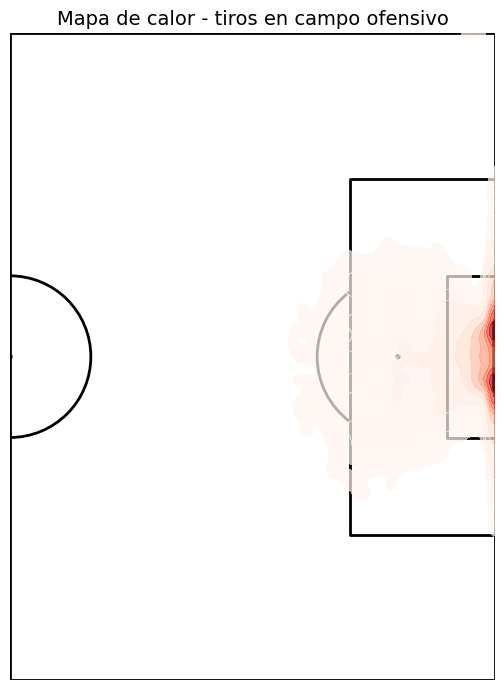

In [17]:
# Extraer tiros
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Crear cancha (StatsBomb 120x80)
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

# Graficar solo medio campo ofensivo (x de 60 a 120)
ax.set_xlim(60, 120)
ax.set_ylim(0, 80)

# Heatmap
sns.kdeplot(
    x=shots['x'], y=shots['y'],
    fill=True, cmap="Reds", bw_adjust=0.5, alpha=0.7, ax=ax
)

ax.set_title("Mapa de calor - tiros en campo ofensivo", fontsize=14)
plt.show()

Entonces podemos ver el heatmap y ver que muchos de los tiros fueron al arco o cerca por la intesidad del calor, entonces a continuacion se grafica en un grafico de 3 dimensiones de puntos, todos los tiros en gris y en verde solo los que fueron goles

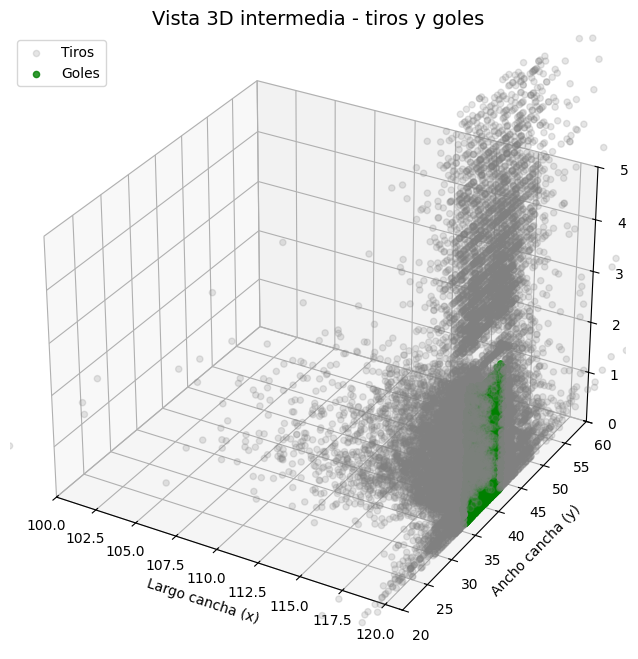

In [ ]:
# Filtrar tiros y extraer coords
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Separar goles y no goles
goals = shots[shots['shot_outcome'] == 'Goal']
no_goals = shots[shots['shot_outcome'] != 'Goal']

# Crear gráfico 3D
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Tiros en gris
ax.scatter(no_goals['x'], no_goals['y'], no_goals['z'], 
           c='gray', alpha=0.2, label='Tiros')

# Goles en verde
ax.scatter(goals['x'], goals['y'], goals['z'], 
           c='green', alpha=0.8, label='Goles')

# Ajustar límites más amplios que antes (zoom intermedio)
ax.set_xlim(100, 121)   # antes era 110–121
ax.set_ylim(20, 60)     # antes era 30–50
ax.set_zlim(0, 5)       # antes era 0–3

# Etiquetas
ax.set_xlabel("Largo cancha (x)")
ax.set_ylabel("Ancho cancha (y)")
ax.set_zlabel("Altura (z)")
ax.set_title("tiros y goles", fontsize=14)

ax.legend()
plt.show()